# Практическое занятие № 5
## Тема: Решение задачи регрессии для прогнозирования

**Задание:** Разработка прототипа системы оценки стоимости домов для риэлтерского агентства (датасет California Housing).

---
## Часть 1. Исследование данных и целевой переменной

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Все библиотеки успешно импортированы.')

Все библиотеки успешно импортированы.


In [7]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # целевая переменная (медианная стоимость в $100 000)

print(f'Размер датасета: {df.shape[0]} объектов, {df.shape[1]} столбцов')
print(f'\nПризнаки: {housing.feature_names}')
print(f'Целевая переменная: MedHouseVal (медианная стоимость дома, в $100 000)')
print()
df.head(10)

Размер датасета: 20640 объектов, 9 столбцов

Признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Целевая переменная: MedHouseVal (медианная стоимость дома, в $100 000)



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [8]:
print('=== Описательная статистика ====')
df.describe().round(3)

=== Описательная статистика ====


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


### Гистограмма целевой переменной MedHouseVal

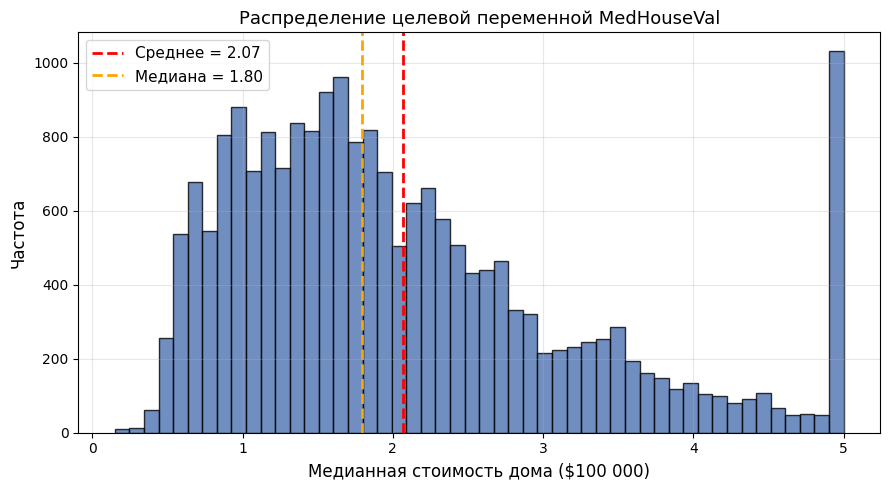

Минимум:  0.150 ($100 000)
Максимум: 5.000 ($100 000)
Среднее:  2.069 ($100 000)
Медиана:  1.797 ($100 000)


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['MedHouseVal'], bins=50, color='#4C72B0', edgecolor='black', alpha=0.8)
ax.axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Среднее = {df["MedHouseVal"].mean():.2f}')
ax.axvline(df['MedHouseVal'].median(), color='orange', linestyle='--', linewidth=2,
           label=f'Медиана = {df["MedHouseVal"].median():.2f}')
ax.set_xlabel('Медианная стоимость дома ($100 000)', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)
ax.set_title('Распределение целевой переменной MedHouseVal', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Минимум:  {df["MedHouseVal"].min():.3f} ($100 000)')
print(f'Максимум: {df["MedHouseVal"].max():.3f} ($100 000)')
print(f'Среднее:  {df["MedHouseVal"].mean():.3f} ($100 000)')
print(f'Медиана:  {df["MedHouseVal"].median():.3f} ($100 000)')

### Выбор признаков и визуализация их связи с целевой переменной

Выберем 3 наиболее понятных признака:
- **MedInc** — медианный доход жителей района (в $10 000). Чем богаче район, тем дороже дома.
- **AveRooms** — среднее число комнат в доме. Больше комнат — больше площадь — выше цена.
- **HouseAge** — медианный возраст домов в районе. Может влиять на цену (новые или исторические дома).

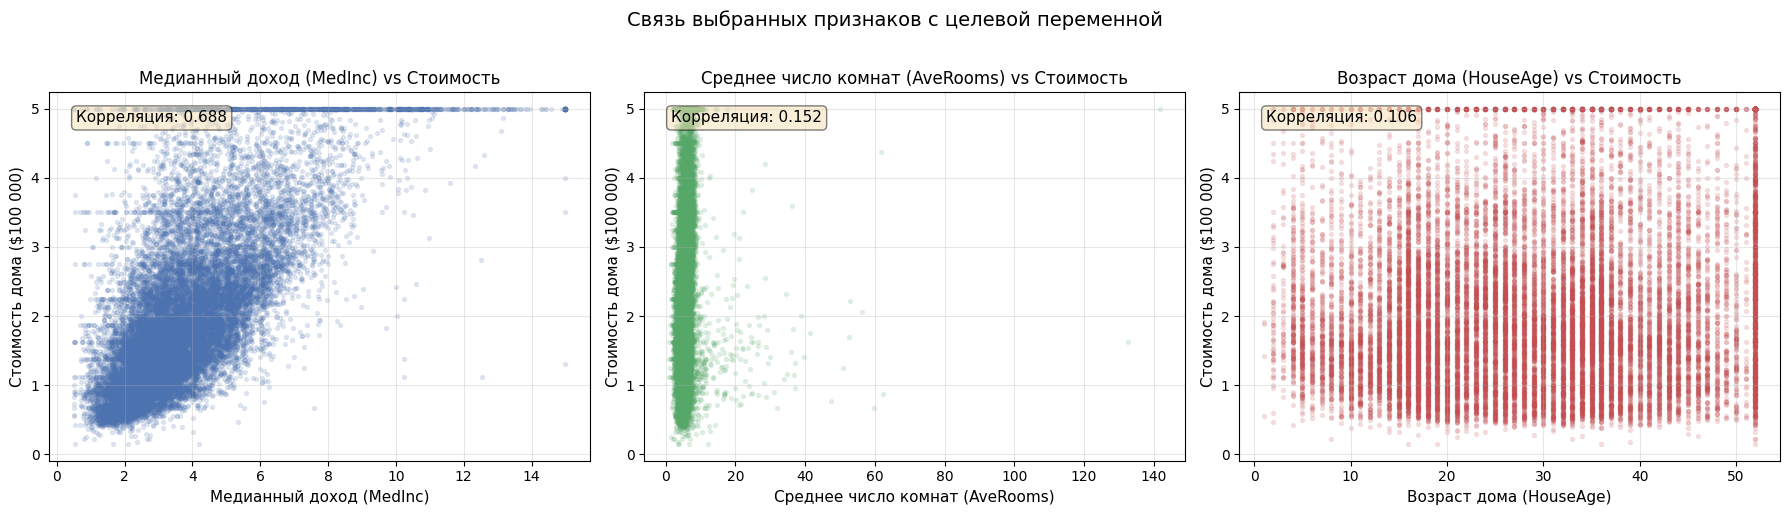

Корреляция признаков с MedHouseVal:
        MedInc: +0.6881
      AveRooms: +0.1519
      HouseAge: +0.1056


In [10]:
selected_features = ['MedInc', 'AveRooms', 'HouseAge']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = [
    'Медианный доход (MedInc)',
    'Среднее число комнат (AveRooms)',
    'Возраст дома (HouseAge)'
]
colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, feat, title, color in zip(axes, selected_features, titles, colors):
    ax.scatter(df[feat], df['MedHouseVal'], alpha=0.15, s=8, color=color)
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Стоимость дома ($100 000)', fontsize=11)
    ax.set_title(f'{title} vs Стоимость', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    corr = df[feat].corr(df['MedHouseVal'])
    ax.text(0.05, 0.95, f'Корреляция: {corr:.3f}',
            transform=ax.transAxes, fontsize=11,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Связь выбранных признаков с целевой переменной', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Корреляция признаков с MedHouseVal:')
for feat in selected_features:
    print(f'  {feat:>12}: {df[feat].corr(df["MedHouseVal"]):+.4f}')

---
## Часть 2. Обучение и оценка линейной модели

In [11]:
X = df[selected_features].values
y = df['MedHouseVal'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Обучающая выборка: {X_train.shape[0]} объектов')
print(f'Тестовая выборка:  {X_test.shape[0]} объектов')
print(f'Используемые признаки: {selected_features}')

Обучающая выборка: 16512 объектов
Тестовая выборка:  4128 объектов
Используемые признаки: ['MedInc', 'AveRooms', 'HouseAge']


In [14]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print('=== Линейная регрессия — метрики на тестовой выборке ===')
print(f'MAE (средняя абсолютная ошибка): {mae_lr:.4f} ($100 000)')
print(f'MSE (средняя квадратичная ошибка): {mse_lr:.4f}')
print(f'R2  (коэффициент детерминации):  {r2_lr:.4f}')
print(f'\nМодель объясняет {r2_lr*100:.1f}% дисперсии цен на жильё.')

=== Линейная регрессия — метрики на тестовой выборке ===
MAE (средняя абсолютная ошибка): 0.6033 ($100 000)
MSE (средняя квадратичная ошибка): 0.6589
R2  (коэффициент детерминации):  0.4972

Модель объясняет 49.7% дисперсии цен на жильё.


### Интерпретация коэффициентов линейной модели

In [15]:
print('=== Коэффициенты линейной модели ===')
print(f'Свободный член (intercept): {lr_model.intercept_:.4f}\n')

print(f'{"Признак":<12} {"Коэффициент":>14} {"Интерпретация"}')
print('-' * 75)
for feat, coef in zip(selected_features, lr_model.coef_):
    print(f'{feat:<12} {coef:>14.4f}', end='   ')
    if feat == 'MedInc':
        print(f'Рост дохода на $10 000 -> стоимость дома +${coef*100_000:.0f}')
    elif feat == 'AveRooms':
        print(f'Увеличение числа комнат на 1 -> стоимость +${coef*100_000:.0f}')
    elif feat == 'HouseAge':
        print(f'Увеличение возраста дома на 1 год -> стоимость {"" if coef >= 0 else "-"}${abs(coef)*100_000:.0f}')

print(f'\n--- Расшифровка для бизнес-заказчика ---')
medinc_coef = lr_model.coef_[0]
print(f'Коэффициент при MedInc = {medinc_coef:.4f}.')
print(f'Это означает: при увеличении медианного дохода района на $10 000')
print(f'прогнозируемая стоимость дома возрастает в среднем на ${medinc_coef * 100_000:,.0f}.')
print(f'\nКоэффициент при AveRooms = {lr_model.coef_[1]:.4f}.')
print(f'Увеличение среднего числа комнат на 1 приводит к росту')
print(f'прогнозируемой стоимости в среднем на ${lr_model.coef_[1] * 100_000:,.0f}.')

=== Коэффициенты линейной модели ===
Свободный член (intercept): 0.0173

Признак         Коэффициент Интерпретация
---------------------------------------------------------------------------
MedInc               0.4448   Рост дохода на $10 000 -> стоимость дома +$44476
AveRooms            -0.0281   Увеличение числа комнат на 1 -> стоимость +$-2815
HouseAge             0.0168   Увеличение возраста дома на 1 год -> стоимость $1684

--- Расшифровка для бизнес-заказчика ---
Коэффициент при MedInc = 0.4448.
Это означает: при увеличении медианного дохода района на $10 000
прогнозируемая стоимость дома возрастает в среднем на $44,476.

Коэффициент при AveRooms = -0.0281.
Увеличение среднего числа комнат на 1 приводит к росту
прогнозируемой стоимости в среднем на $-2,815.


---
## Часть 3. Сравнение с нелинейной моделью (DecisionTreeRegressor)

In [16]:
dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt  = r2_score(y_test, y_pred_dt)

print('=== Дерево решений (max_depth=3) — метрики на тестовой выборке ===')
print(f'MAE: {mae_dt:.4f}')
print(f'MSE: {mse_dt:.4f}')
print(f'R2:  {r2_dt:.4f}')

=== Дерево решений (max_depth=3) — метрики на тестовой выборке ===
MAE: 0.6144
MSE: 0.6890
R2:  0.4742


### Сравнение метрик линейной модели и дерева решений

In [17]:
print('=' * 55)
print(f'{"Метрика":<10} {"LinearRegression":>18} {"DecisionTree":>16}')
print('=' * 55)
print(f'{"MAE":<10} {mae_lr:>18.4f} {mae_dt:>16.4f}')
print(f'{"MSE":<10} {mse_lr:>18.4f} {mse_dt:>16.4f}')
print(f'{"R2":<10} {r2_lr:>18.4f} {r2_dt:>16.4f}')
print('=' * 55)

if r2_dt > r2_lr:
    best_name = 'DecisionTreeRegressor'
    best_r2 = r2_dt
    best_pred = y_pred_dt
    print(f'\nДерево решений показало лучший результат (R2 = {r2_dt:.4f} > {r2_lr:.4f}).')
else:
    best_name = 'LinearRegression'
    best_r2 = r2_lr
    best_pred = y_pred_lr
    print(f'\nЛинейная регрессия показала лучший результат (R2 = {r2_lr:.4f} > {r2_dt:.4f}).')

print(f'Лучшая модель: {best_name}')

Метрика      LinearRegression     DecisionTree
MAE                    0.6033           0.6144
MSE                    0.6589           0.6890
R2                     0.4972           0.4742

Линейная регрессия показала лучший результат (R2 = 0.4972 > 0.4742).
Лучшая модель: LinearRegression


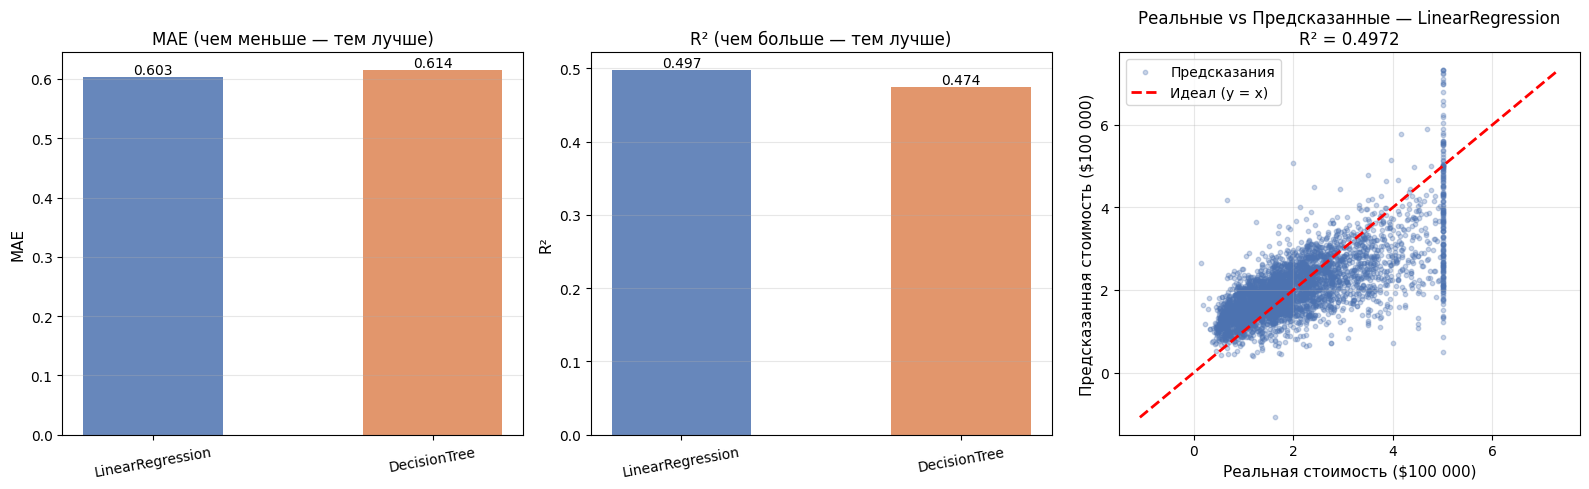


На scatter plot видно, насколько предсказания лучшей модели (LinearRegression)
близки к идеальной прямой y = x.
Чем ближе точки к красной линии, тем точнее модель.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_labels = ['LinearRegression', 'DecisionTree']
x = np.arange(len(models_labels))
width = 0.5

mae_vals = [mae_lr, mae_dt]
bars_mae = axes[0].bar(x, mae_vals, width, color=['#4C72B0', '#DD8452'], alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_labels, fontsize=10, rotation=10)
axes[0].set_title('MAE (чем меньше — тем лучше)', fontsize=12)
axes[0].set_ylabel('MAE', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars_mae, mae_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                 f'{val:.3f}', ha='center', fontsize=10)

r2_vals = [r2_lr, r2_dt]
bars_r2 = axes[1].bar(x, r2_vals, width, color=['#4C72B0', '#DD8452'], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_labels, fontsize=10, rotation=10)
axes[1].set_title('R² (чем больше — тем лучше)', fontsize=12)
axes[1].set_ylabel('R²', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars_r2, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                 f'{val:.3f}', ha='center', fontsize=10)

axes[2].scatter(y_test, best_pred, alpha=0.3, s=10, color='#4C72B0', label='Предсказания')
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеал (y = x)')
axes[2].set_xlabel('Реальная стоимость ($100 000)', fontsize=11)
axes[2].set_ylabel('Предсказанная стоимость ($100 000)', fontsize=11)
axes[2].set_title(f'Реальные vs Предсказанные — {best_name}\nR\u00b2 = {best_r2:.4f}', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nНа scatter plot видно, насколько предсказания лучшей модели ({best_name})')
print(f'близки к идеальной прямой y = x.')
print(f'Чем ближе точки к красной линии, тем точнее модель.')